In [2]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent

behavior = pd.read_csv(
    project_root / "data" / "processed" / "rule_engine_output.csv"
)

print("Dataset shape:", behavior.shape)
print("Columns:", behavior.columns.tolist())

Dataset shape: (11162, 45)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit', 'housing_num', 'loan_num', 'default_num', 'contact_num', 'education_num', 'age_z', 'balance_z', 'campaign_z', 'previous_z', 'duration_z', 'Financial_Stability', 'Contact_Intensity', 'Relationship_History', 'Investment_Experience', 'Responsiveness', 'Investment_Readiness', 'Financial_Index', 'Engagement_Index', 'Investor_Profile_Index', 'Behavioral_Intelligence_Score', 'Financial_Level', 'Engagement_Level', 'Profile_Level', 'Persona', 'Tier', 'Priority', 'Action', 'Rule_Match_Status']


In [3]:
persona_counts = (
    behavior["Persona"]
    .value_counts()
    .rename_axis("Persona")
    .reset_index(name="Customers")
)

persona_counts["Percentage"] = (
    persona_counts["Customers"] / len(behavior) * 100
).round(2)

persona_counts

AttributeError: module 'numpy' has no attribute 'matrix'

In [4]:
persona_counts = (
    behavior["Persona"]
    .value_counts()
    .reset_index()
)

persona_counts.columns = ["Persona", "Customers"]

persona_counts["Percentage"] = (
    persona_counts["Customers"].astype(float)
    / len(behavior)
    * 100
).round(2)

print(persona_counts)

AttributeError: module 'numpy' has no attribute 'matrix'

In [5]:
counts = behavior["Persona"].value_counts()

total = len(behavior)

print("Persona Distribution")
print("=" * 50)

for persona, count in counts.items():
    percentage = (count / total) * 100
    print(f"{persona:<25} {count:>6}  ({percentage:>6.2f}%)")

print("=" * 50)
print(f"Total{'':<26}{total:>6}  (100.00%)")

Persona Distribution
Inactive Investor           2378  ( 21.30%)
Balanced Investor           2151  ( 19.27%)
General Investor            1873  ( 16.78%)
Low Engagement User         1455  ( 13.04%)
Emerging Investor           1168  ( 10.46%)
Potential Investor           926  (  8.30%)
Dormant Wealth Holder        555  (  4.97%)
Growth Investor              433  (  3.88%)
Premium Investor             223  (  2.00%)
Total                           11162  (100.00%)


In [6]:
persona_behavior = (
    behavior
    .groupby("Persona")[
        [
            "Financial_Index",
            "Engagement_Index",
            "Investor_Profile_Index",
            "Behavioral_Intelligence_Score"
        ]
    ]
    .mean()
)

print(persona_behavior.round(3).to_string())

                       Financial_Index  Engagement_Index  Investor_Profile_Index  Behavioral_Intelligence_Score
Persona                                                                                                        
Balanced Investor                0.140             0.709                   0.857                          0.827
Dormant Wealth Holder            1.470            -0.627                  -0.480                          0.225
Emerging Investor               -0.645             0.631                  -0.217                         -0.105
General Investor                -0.073            -0.055                  -0.366                         -0.230
Growth Investor                  1.568             0.438                   0.784                          1.398
Inactive Investor                0.096            -0.798                  -0.571                         -0.622
Low Engagement User             -0.731            -0.604                  -0.734                        

In [8]:
personas = behavior["Persona"].dropna().unique()

print("Dominant behavioral levels by persona")
print("=" * 75)

for persona in sorted(personas):

    subset = behavior[behavior["Persona"] == persona]

    financial = subset["Financial_Level"].value_counts().idxmax()
    engagement = subset["Engagement_Level"].value_counts().idxmax()
    profile = subset["Profile_Level"].value_counts().idxmax()

    print(
        f"{persona:<25} "
        f"Financial: {financial:<8} "
        f"Engagement: {engagement:<8} "
        f"Profile: {profile:<8}"
    )

Dominant behavioral levels by persona
Balanced Investor         Financial: Medium   Engagement: High     Profile: High    
Dormant Wealth Holder     Financial: High     Engagement: Low      Profile: Low     
Emerging Investor         Financial: Low      Engagement: High     Profile: Medium  
General Investor          Financial: Medium   Engagement: Medium   Profile: Medium  
Growth Investor           Financial: High     Engagement: Medium   Profile: High    
Inactive Investor         Financial: Medium   Engagement: Low      Profile: Medium  
Low Engagement User       Financial: Low      Engagement: Low      Profile: Low     
Potential Investor        Financial: Low      Engagement: High     Profile: High    
Premium Investor          Financial: High     Engagement: High     Profile: High    


In [1]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent

behavior = pd.read_csv(
    project_root / "data" / "processed" / "rule_engine_output.csv"
)

print("Shape:", behavior.shape)
print("Personas:", behavior["Persona"].nunique())
print("Metrics available:")

for col in [
    "Financial_Index",
    "Engagement_Index",
    "Investor_Profile_Index",
    "Behavioral_Intelligence_Score"
]:
    print(col, "✓" if col in behavior.columns else "MISSING")

Shape: (11162, 45)
Personas: 9
Metrics available:
Financial_Index ✓
Engagement_Index ✓
Investor_Profile_Index ✓
Behavioral_Intelligence_Score ✓


In [2]:
from scipy.stats import kruskal

groups = []

for persona in behavior["Persona"].dropna().unique():
    values = behavior.loc[
        behavior["Persona"] == persona,
        "Financial_Index"
    ].dropna().to_numpy()

    groups.append(values)

H, p = kruskal(*groups)

N = sum(len(g) for g in groups)
k = len(groups)

epsilon_squared = max(
    0,
    (H - k + 1) / (N - k)
)

print("Financial Index")
print("-" * 40)
print(f"Kruskal-Wallis H : {H:.4f}")
print(f"p-value          : {p:.6g}")
print(f"Epsilon-squared  : {epsilon_squared:.4f}")

Financial Index
----------------------------------------
Kruskal-Wallis H : 7318.5542
p-value          : 0
Epsilon-squared  : 0.6555


In [3]:
groups = []

for persona in behavior["Persona"].dropna().unique():
    values = behavior.loc[
        behavior["Persona"] == persona,
        "Engagement_Index"
    ].dropna().to_numpy()

    groups.append(values)

H, p = kruskal(*groups)

N = sum(len(g) for g in groups)
k = len(groups)

epsilon_squared = max(
    0,
    (H - k + 1) / (N - k)
)

print("Engagement Index")
print("-" * 40)
print(f"Kruskal-Wallis H : {H:.4f}")
print(f"p-value          : {p:.6g}")
print(f"Epsilon-squared  : {epsilon_squared:.4f}")

Engagement Index
----------------------------------------
Kruskal-Wallis H : 7224.3563
p-value          : 0
Epsilon-squared  : 0.6470


In [5]:
groups = []

for persona in behavior["Persona"].dropna().unique():
    values = behavior.loc[
        behavior["Persona"] == persona,
        "Investor_Profile_Index"
    ].dropna().to_numpy()

    groups.append(values)

H, p = kruskal(*groups)

N = sum(len(g) for g in groups)
k = len(groups)

epsilon_squared = max(
    0,
    (H - k + 1) / (N - k)
)

print("Investor Profile Index")
print("-" * 40)
print(f"Kruskal-Wallis H : {H:.4f}")
print(f"p-value          : {p:.6g}")
print(f"Epsilon-squared  : {epsilon_squared:.4f}")

Investor Profile Index
----------------------------------------
Kruskal-Wallis H : 6022.0749
p-value          : 0
Epsilon-squared  : 0.5392


In [6]:
from itertools import combinations
from scipy.stats import rankdata, norm
import numpy as np

In [ ]:
metric = "Financial_Index"

temp = behavior[["Persona", metric]].dropna()

# Rank all observations together
ranks = rankdata(temp[metric].to_numpy(), method="average")

N = len(temp)
groups = temp["Persona"].unique()

results = []

# Tie correction
_, counts = np.unique(temp[metric].to_numpy(), return_counts=True)
tie_sum = np.sum(counts**3 - counts)

tie_correction = 1 - tie_sum / (N**3 - N)

for g1, g2 in combinations(groups, 2):

    mask1 = temp["Persona"].to_numpy() == g1
    mask2 = temp["Persona"].to_numpy() == g2

    n1 = mask1.sum()
    n2 = mask2.sum()

    mean_rank_1 = ranks[mask1].mean()
    mean_rank_2 = ranks[mask2].mean()

    denominator = np.sqrt(
        tie_correction
        * N * (N + 1) / 12
        * (1/n1 + 1/n2)
    )

    z = (mean_rank_1 - mean_rank_2) / denominator

    p = 2 * norm.sf(abs(z))

    results.append((g1, g2, z, p))

# Sort by raw p-value
results.sort(key=lambda x: x[3])

# Holm correction
m = len(results)
adjusted = []

for i, (_, _, _, p) in enumerate(results):
    adjusted.append(min(1, p * (m - i)))

# Ensure Holm-adjusted p-values are monotonic
for i in range(1, len(adjusted)):
    adjusted[i] = max(adjusted[i], adjusted[i-1])

print("=" * 90)
print("DUNN POST-HOC — FINANCIAL INDEX")
print("=" * 90)

for (g1, g2, z, p), p_adj in zip(results, adjusted):

    print(
        f"{g1:<25} vs {g2:<25} "
        f"z = {z:>8.3f}   "
        f"Holm p = {p_adj:.3e}"
    )

DUNN POST-HOC — FINANCIAL INDEX
Balanced Investor         vs Emerging Investor         z =   39.142   Holm p = 0.000e+00
Balanced Investor         vs Low Engagement User       z =   47.505   Holm p = 0.000e+00
General Investor          vs Low Engagement User       z =   41.531   Holm p = 0.000e+00
Potential Investor        vs Dormant Wealth Holder     z =  -39.814   Holm p = 0.000e+00
Emerging Investor         vs Growth Investor           z =  -45.156   Holm p = 0.000e+00
Emerging Investor         vs Dormant Wealth Holder     z =  -49.025   Holm p = 0.000e+00
Emerging Investor         vs Inactive Investor         z =  -40.193   Holm p = 0.000e+00
Growth Investor           vs Low Engagement User       z =   49.879   Holm p = 0.000e+00
Low Engagement User       vs Premium Investor          z =  -37.786   Holm p = 0.000e+00
Low Engagement User       vs Dormant Wealth Holder     z =  -54.466   Holm p = 0.000e+00
Low Engagement User       vs Inactive Investor         z =  -48.852   Holm p =

In [12]:
metric = "Engagement_Index"

print("Metric being tested:", metric)

print("\nEngagement means by persona:")
print(
    behavior.groupby("Persona")[metric]
    .mean()
    .round(3)
    .sort_values(ascending=False)
    .to_string()
)

Metric being tested: Engagement_Index

Engagement means by persona:
Persona
Premium Investor         1.440
Balanced Investor        0.709
Emerging Investor        0.631
Potential Investor       0.492
Growth Investor          0.438
General Investor        -0.055
Low Engagement User     -0.604
Dormant Wealth Holder   -0.627
Inactive Investor       -0.798


In [13]:
from itertools import combinations
from scipy.stats import rankdata, norm
import numpy as np

metric = "Engagement_Index"

temp = behavior[["Persona", metric]].dropna()

values = temp[metric].to_numpy()
labels = temp["Persona"].to_numpy()

# Rank all observations together
ranks = rankdata(values, method="average")

N = len(values)
groups = temp["Persona"].unique()

# Tie correction
_, counts = np.unique(values, return_counts=True)
tie_sum = np.sum(counts**3 - counts)

tie_correction = 1 - tie_sum / (N**3 - N)

results = []

for g1, g2 in combinations(groups, 2):

    mask1 = labels == g1
    mask2 = labels == g2

    n1 = mask1.sum()
    n2 = mask2.sum()

    mean_rank_1 = ranks[mask1].mean()
    mean_rank_2 = ranks[mask2].mean()

    denominator = np.sqrt(
        tie_correction
        * N * (N + 1) / 12
        * (1 / n1 + 1 / n2)
    )

    z = (mean_rank_1 - mean_rank_2) / denominator

    p = 2 * norm.sf(abs(z))

    results.append((g1, g2, z, p))

# Sort by raw p-value
results.sort(key=lambda x: x[3])

# Holm correction
m = len(results)
adjusted = []

for i, (_, _, _, p) in enumerate(results):
    adjusted.append(min(1, p * (m - i)))

# Ensure monotonicity
for i in range(1, len(adjusted)):
    adjusted[i] = max(adjusted[i], adjusted[i - 1])

print("=" * 90)
print("DUNN POST-HOC — ENGAGEMENT INDEX")
print("=" * 90)

for (g1, g2, z, raw_p), adjusted_p in zip(results, adjusted):

    print(
        f"{g1:<25} vs {g2:<25} "
        f"z = {z:>8.3f}   "
        f"Holm p = {adjusted_p:.3e}"
    )

DUNN POST-HOC — ENGAGEMENT INDEX
Balanced Investor         vs Low Engagement User       z =   47.915   Holm p = 0.000e+00
Balanced Investor         vs Inactive Investor         z =   66.083   Holm p = 0.000e+00
General Investor          vs Inactive Investor         z =   41.888   Holm p = 0.000e+00
Emerging Investor         vs Low Engagement User       z =   40.296   Holm p = 0.000e+00
Emerging Investor         vs Inactive Investor         z =   53.821   Holm p = 0.000e+00
Potential Investor        vs Inactive Investor         z =   36.758   Holm p = 2.657e-294
Premium Investor          vs Inactive Investor         z =   35.357   Holm p = 2.377e-272
Balanced Investor         vs Dormant Wealth Holder     z =   34.586   Holm p = 1.187e-260
Growth Investor           vs Inactive Investor         z =   33.166   Holm p = 9.466e-240
Emerging Investor         vs Dormant Wealth Holder     z =   31.099   Holm p = 6.657e-211
Low Engagement User       vs Premium Investor          z =  -29.705   Ho

In [14]:
print("Number of Dunn comparisons:", len(results))

Number of Dunn comparisons: 36


In [15]:
metric = "Investor_Profile_Index"

print("Metric being tested:", metric)

print("\nInvestor Profile means by persona:")
print(
    behavior.groupby("Persona")[metric]
    .mean()
    .round(3)
    .sort_values(ascending=False)
    .to_string()
)

Metric being tested: Investor_Profile_Index

Investor Profile means by persona:
Persona
Premium Investor         1.520
Potential Investor       1.197
Balanced Investor        0.857
Growth Investor          0.784
Emerging Investor       -0.217
General Investor        -0.366
Dormant Wealth Holder   -0.480
Inactive Investor       -0.571
Low Engagement User     -0.734


In [16]:
metric = "Investor_Profile_Index"

temp = behavior[["Persona", metric]].dropna()

values = temp[metric].to_numpy()
labels = temp["Persona"].to_numpy()

# Rank all observations together
ranks = rankdata(values, method="average")

N = len(values)
groups = temp["Persona"].unique()

# Tie correction
_, counts = np.unique(values, return_counts=True)
tie_sum = np.sum(counts**3 - counts)

tie_correction = 1 - tie_sum / (N**3 - N)

results = []

for g1, g2 in combinations(groups, 2):

    mask1 = labels == g1
    mask2 = labels == g2

    n1 = mask1.sum()
    n2 = mask2.sum()

    mean_rank_1 = ranks[mask1].mean()
    mean_rank_2 = ranks[mask2].mean()

    denominator = np.sqrt(
        tie_correction
        * N * (N + 1) / 12
        * (1 / n1 + 1 / n2)
    )

    z = (mean_rank_1 - mean_rank_2) / denominator

    p = 2 * norm.sf(abs(z))

    results.append((g1, g2, z, p))

# Sort by raw p-value
results.sort(key=lambda x: x[3])

# Holm correction
m = len(results)
adjusted = []

for i, (_, _, _, p) in enumerate(results):
    adjusted.append(min(1, p * (m - i)))

# Enforce monotonicity
for i in range(1, len(adjusted)):
    adjusted[i] = max(adjusted[i], adjusted[i - 1])

print("=" * 90)
print("DUNN POST-HOC — INVESTOR PROFILE INDEX")
print("=" * 90)

for (g1, g2, z, raw_p), adjusted_p in zip(results, adjusted):

    print(
        f"{g1:<25} vs {g2:<25} "
        f"z = {z:>8.3f}   "
        f"Holm p = {adjusted_p:.3e}"
    )

DUNN POST-HOC — INVESTOR PROFILE INDEX
Balanced Investor         vs General Investor          z =   39.175   Holm p = 0.000e+00
Balanced Investor         vs Low Engagement User       z =   50.294   Holm p = 0.000e+00
Balanced Investor         vs Inactive Investor         z =   49.743   Holm p = 0.000e+00
General Investor          vs Potential Investor        z =  -39.151   Holm p = 0.000e+00
Potential Investor        vs Low Engagement User       z =   48.573   Holm p = 0.000e+00
Potential Investor        vs Inactive Investor         z =   46.853   Holm p = 0.000e+00
Potential Investor        vs Dormant Wealth Holder     z =   33.208   Holm p = 2.488e-240
Potential Investor        vs Emerging Investor         z =   31.445   Holm p = 1.436e-215
Balanced Investor         vs Dormant Wealth Holder     z =   30.412   Holm p = 1.062e-201
Low Engagement User       vs Premium Investor          z =  -30.098   Holm p = 1.378e-197
Growth Investor           vs Low Engagement User       z =   30.021

In [17]:
print("\nTotal Dunn comparisons:", len(results))

non_significant = [
    (g1, g2, p_adj)
    for (g1, g2, z, raw_p), p_adj in zip(results, adjusted)
    if p_adj >= 0.05
]

print("Non-significant pairs:", len(non_significant))

for g1, g2, p_adj in non_significant:
    print(f"{g1} vs {g2}: Holm p = {p_adj:.3f}")


Total Dunn comparisons: 36
Non-significant pairs: 3
Potential Investor vs Premium Investor: Holm p = 0.301
Balanced Investor vs Growth Investor: Holm p = 0.453
Dormant Wealth Holder vs Inactive Investor: Holm p = 0.494


In [18]:
# ============================================================
# FINAL EVALUATION SUMMARY
# ============================================================

print("=" * 80)
print("NUDGEIQ — FINAL BEHAVIORAL SEGMENTATION EVALUATION")
print("=" * 80)

print("\nDataset")
print("-" * 80)
print("Customers:", len(behavior))
print("Personas:", behavior["Persona"].nunique())

print("\nRule Engine")
print("-" * 80)
print("Matched:", (behavior["Rule_Match_Status"] == "Matched").sum())
print("Unmatched:", (behavior["Rule_Match_Status"] == "Unmatched").sum())

print("\nIndex Correlations")
print("-" * 80)

correlation_matrix = behavior[
    [
        "Financial_Index",
        "Engagement_Index",
        "Investor_Profile_Index"
    ]
].corr()

print(correlation_matrix.round(3))

print("\nKruskal-Wallis + Effect Size")
print("-" * 80)

print("Financial Index       : H = 7318.55 | p < 0.001 | ε² = 0.656")
print("Engagement Index      : H = 7224.36 | p < 0.001 | ε² = 0.647")
print("Investor Profile      : H = 6022.08 | p < 0.001 | ε² = 0.539")

print("\nDunn + Holm")
print("-" * 80)

print("Financial Index       : 32/36 significant")
print("Engagement Index      : 34/36 significant")
print("Investor Profile      : 33/36 significant")

print("\nBIS — Descriptive Only")
print("-" * 80)

bis_summary = (
    behavior.groupby("Persona")["Behavioral_Intelligence_Score"]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

print(bis_summary.to_string())

print("\n" + "=" * 80)
print("EVALUATION COMPLETE")
print("=" * 80)

NUDGEIQ — FINAL BEHAVIORAL SEGMENTATION EVALUATION

Dataset
--------------------------------------------------------------------------------
Customers: 11162
Personas: 9

Rule Engine
--------------------------------------------------------------------------------
Matched: 11162
Unmatched: 0

Index Correlations
--------------------------------------------------------------------------------
                        Financial_Index  Engagement_Index  \
Financial_Index                   1.000            -0.038   
Engagement_Index                 -0.038             1.000   
Investor_Profile_Index            0.107             0.482   

                        Investor_Profile_Index  
Financial_Index                          0.107  
Engagement_Index                         0.482  
Investor_Profile_Index                   1.000  

Kruskal-Wallis + Effect Size
--------------------------------------------------------------------------------
Financial Index       : H = 7318.55 | p < 0.001 | ε² = 

In [19]:
persona_evidence = (
    behavior.groupby("Persona")[
        [
            "Financial_Index",
            "Engagement_Index",
            "Investor_Profile_Index",
            "Behavioral_Intelligence_Score"
        ]
    ]
    .mean()
    .round(3)
    .sort_values("Behavioral_Intelligence_Score", ascending=False)
)

print(persona_evidence.to_string())

                       Financial_Index  Engagement_Index  Investor_Profile_Index  Behavioral_Intelligence_Score
Persona                                                                                                        
Premium Investor                 1.609             1.440                   1.520                          2.272
Growth Investor                  1.568             0.438                   0.784                          1.398
Balanced Investor                0.140             0.709                   0.857                          0.827
Potential Investor              -0.466             0.492                   1.197                          0.550
Dormant Wealth Holder            1.470            -0.627                  -0.480                          0.225
Emerging Investor               -0.645             0.631                  -0.217                         -0.105
General Investor                -0.073            -0.055                  -0.366                        

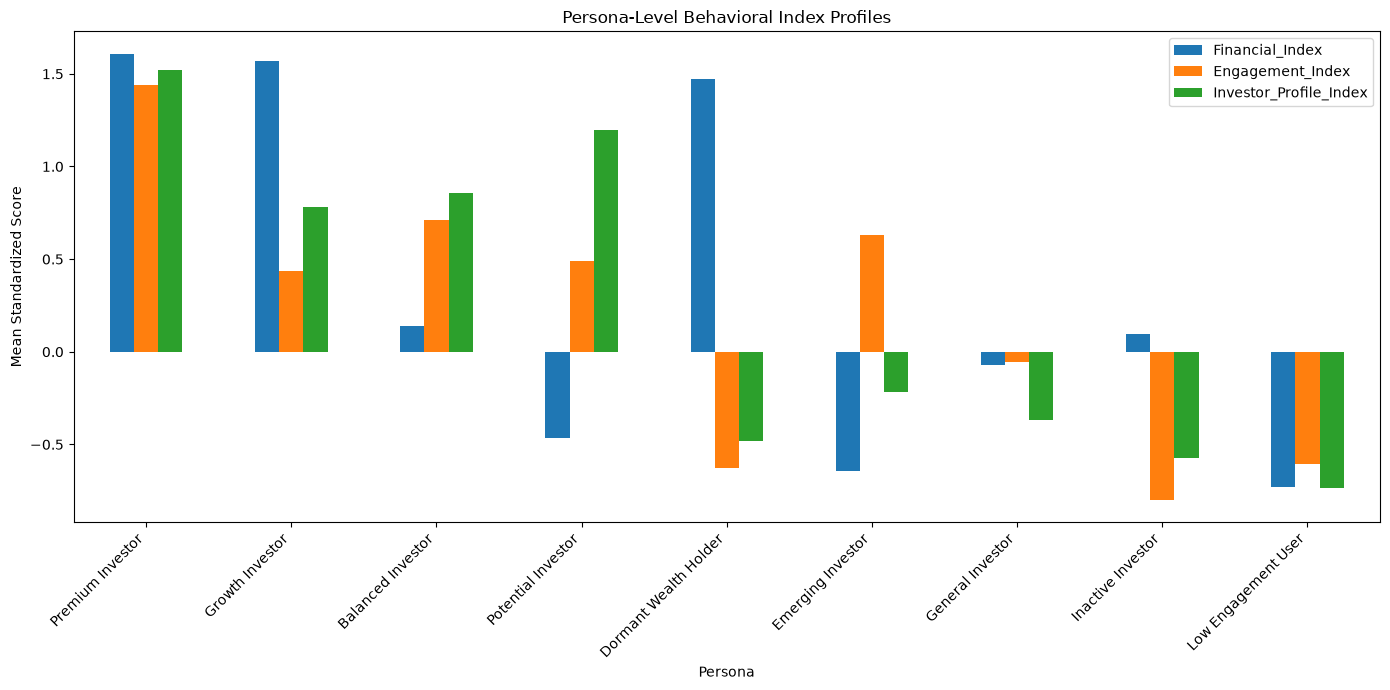

In [20]:
import matplotlib.pyplot as plt

plot_data = persona_evidence[
    [
        "Financial_Index",
        "Engagement_Index",
        "Investor_Profile_Index"
    ]
]

plot_data.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Persona-Level Behavioral Index Profiles")
plt.xlabel("Persona")
plt.ylabel("Mean Standardized Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [21]:
final_output_path = (
    project_root
    / "data"
    / "processed"
    / "final_evaluated_segmentation.csv"
)

behavior.to_csv(
    final_output_path,
    index=False
)

print("Saved:", final_output_path)
print("Rows:", len(behavior))
print("Columns:", len(behavior.columns))

Saved: d:\NudgeIQ\data\processed\final_evaluated_segmentation.csv
Rows: 11162
Columns: 45
